# Load Parameters

In [1]:
import json 
import os

path = "./params/folder_results_mnist_results_20260613_150008/"

files = os.listdir(path=path)

print(files)

json_file = None

with open(os.path.join(path, "model_results.json"), 'r', encoding='utf-8') as f:
    json_file = json.load(f)

['softmax-10-bias.npz', 'neural-9-weights.npz', 'conv2d-1-bias.npz', 'pool-2-bias.npz', 'conv2d-3-weights.npz', 'conv2d-3-bias.npz', 'model_results.json', 'pool-6-bias.npz', 'conv2d-5-weights.npz', 'neural-8-bias.npz', 'pool-6-weights.npz', 'pool-2-weights.npz', 'pool-4-bias.npz', 'conv2d-1-weights.npz', 'pool-4-weights.npz', 'flatten-7-weights.npz', 'neural-8-weights.npz', 'neural-9-bias.npz', 'softmax-10-weights.npz', 'conv2d-5-bias.npz', 'flatten-7-bias.npz']


In [2]:
layer_map = ['neural', 'conv2d', 'pool', 'flatten']

model_conf = json_file['configuration']
len(model_conf)

10

In [3]:
import os
import numpy as np


def load_npz_array(file_path: str, key: str, dtype=np.float32):
    data = np.load(file_path, allow_pickle=True)
    arr = data[key]

    if isinstance(arr, np.ndarray) and arr.dtype == object:
        if arr.shape == ():
            arr = arr.item()
        else:
            arr = np.array(arr.tolist())

    arr = np.asarray(arr, dtype=dtype)

    return arr


weights_bias = {}

for i in model_conf:
    has_forward = i["forward"]
    model_name = i["name"]

    if has_forward:
        weights_path = os.path.join(path, i["wparam"])
        bias_path = os.path.join(path, i["bparam"])

        w_matrix = load_npz_array(weights_path, "weights")
        b_matrix = load_npz_array(bias_path, "bias")

        print(
            w_matrix.shape,
            w_matrix.dtype,
            b_matrix.shape,
            b_matrix.dtype,
            model_name
        )

        weights_bias[model_name] = {
            "w": w_matrix,
            "b": b_matrix
        }

    else:
        weights_bias[model_name] = None

(8, 1, 3, 3) float32 (8,) float32 conv2d-1
(1,) float32 (1,) float32 pool-2
(16, 8, 3, 3) float32 (16,) float32 conv2d-3
(1,) float32 (1,) float32 pool-4
(32, 16, 3, 3) float32 (32,) float32 conv2d-5
(1,) float32 (1,) float32 pool-6
(1,) float32 (1,) float32 flatten-7
(32, 16) float32 (1, 16) float32 neural-8
(16, 10) float32 (1, 10) float32 neural-9
(1,) float32 (1,) float32 softmax-10


# Model

In [4]:
import numpy as np


class NeuralNetwork:
    def __init__(self, W: np.ndarray, b: np.ndarray):
        self.W = W
        self.b = b

    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W + self.b
        return np.maximum(0.0, z)


class Convolution2D:
    def __init__(
        self,
        in_channel: int,
        out_channel: int,
        k_size: int,
        stride: int,
        W: np.ndarray,
        b: np.ndarray,
    ):
        self.W = W
        self.b = b
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.k_size = k_size
        self.stride = stride

    def im2col(self, x: np.ndarray, k_size: int, stride: int = 1) -> np.ndarray:
        C, H, W = x.shape
        H_out = (H - k_size) // stride + 1
        W_out = (W - k_size) // stride + 1

        shape = (C, H_out, W_out, k_size, k_size)
        strides = (
            x.strides[0],
            x.strides[1] * stride,
            x.strides[2] * stride,
            x.strides[1],
            x.strides[2],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        col = patches.transpose(0, 3, 4, 1, 2).reshape(C * k_size * k_size, -1)
        return col

    def forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W_img = x.shape

        if C != self.in_channel:
            raise ValueError(
                f"Channel input {C} tidak sesuai dengan in_channel={self.in_channel}."
            )
        if H < self.k_size or W_img < self.k_size:
            raise ValueError(
                f"Kernel size {self.k_size} lebih besar dari "
                f"spatial input ({H}x{W_img})."
            )

        H_out = (H - self.k_size) // self.stride + 1
        W_out = (W_img - self.k_size) // self.stride + 1

        col   = self.im2col(x, self.k_size, self.stride)
        W_col = self.W.reshape(self.out_channel, -1)

        z = W_col @ col
        z += self.b[:, np.newaxis]
        z = z.reshape(self.out_channel, H_out, W_out)

        return np.maximum(0.0, z)


class MaxPooling:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        if x.ndim != 3:
            raise ValueError(
                f"Input harus 3-D (C, H, W), dapat {x.shape}."
            )
        return self._local_forward(x)

    def _local_forward(self, x: np.ndarray) -> np.ndarray:
        C, H, W = x.shape
        k, s = 2, 2

        if H < k or W < k:
            raise ValueError(
                f"Kernel ({k}x{k}) lebih besar dari spatial input ({H}x{W})."
            )

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        shape = (C, H_out, W_out, k, k)
        strides = (
            x.strides[0],
            x.strides[1] * s,
            x.strides[2] * s,
            x.strides[1],
            x.strides[2],
        )
        windows = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

        out = windows.reshape(C, H_out, W_out, k * k).max(axis=-1)
        return out


class FlattenLayer:
    def __init__(self):
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x.flatten()


class SoftmaxLayer:
    def __init__(self):
        pass

    def forward(self, z: np.ndarray) -> np.ndarray:
        z_shifted = z - np.max(z)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z)

# Model Load and Defenitions

In [5]:
conv1_weights = weights_bias['conv2d-1']['w']
conv1_bias = weights_bias['conv2d-1']['b']
conv1 = Convolution2D(1, 8, 3, 1, conv1_weights, conv1_bias)

conv2_weights = weights_bias['conv2d-3']['w']
conv2_bias = weights_bias['conv2d-3']['b']
conv2 = Convolution2D(8, 16, 3, 1, conv2_weights, conv2_bias)

conv3_weights = weights_bias['conv2d-5']['w']
conv3_bias = weights_bias['conv2d-5']['b']
conv3 = Convolution2D(16, 32, 3, 1, conv3_weights, conv3_bias)

In [6]:
neural1_weights = weights_bias["neural-8"]["w"]
neural1_bias = weights_bias["neural-8"]["b"]
neural1 = NeuralNetwork(neural1_weights, neural1_bias)

neural2_weights = weights_bias["neural-9"]["w"]
neural2_bias = weights_bias["neural-9"]["b"]
neural2 = NeuralNetwork(neural2_weights, neural2_bias)

In [7]:
pool = MaxPooling()

In [8]:
flatten = FlattenLayer()

In [9]:
softmax = SoftmaxLayer()

# Data

In [10]:
import numpy as np
from pathlib import Path

def load_mem_image(file_path, shape=(28, 28), normalize=True):
    """
    Membaca file .mem berisi 1 pixel hex per baris.
    Output default:
        shape: 28x28
        range: 0.0 - 1.0
    """

    file_path = Path(file_path)

    values = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # skip baris kosong
            if not line:
                continue

            # kalau ada comment
            line = line.split("//")[0].strip()
            line = line.split("#")[0].strip()

            if not line:
                continue

            # parse hex, contoh: "00", "7F", "FF"
            values.append(int(line, 16))

    arr = np.array(values, dtype=np.uint8)

    expected_size = np.prod(shape)
    if arr.size != expected_size:
        raise ValueError(
            f"Jumlah pixel salah. Dapat {arr.size}, expected {expected_size} untuk shape {shape}"
        )

    arr = arr.reshape(shape)

    if normalize:
        arr = arr.astype(np.float32) / 255.0

    return arr

In [11]:
img = load_mem_image("./image-hex-gen/mnist_img_0/img_0.mem", normalize=False)

print(img.shape)
print(img.min(), img.max())

(28, 28)
0 255


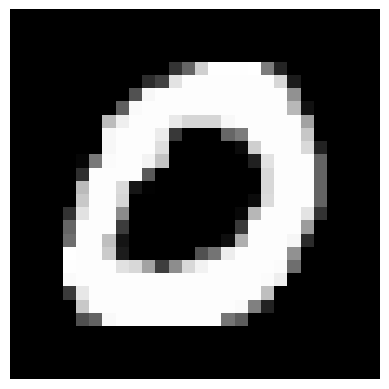

In [12]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

# Check

In [13]:
def full_predict(x):
    x_sample = x[0]
    x_sample = x_sample.reshape(1, 28, 28)

    res = conv1.forward(x_sample)
    res = pool.forward(res)
    res = conv2.forward(res)
    res = pool.forward(res)
    res = conv3.forward(res)
    res = pool.forward(res)
    res = flatten.forward(res)
    res = neural1.forward(res)
    res = neural2.forward(res)
    res = softmax.forward(res)
    argmax = np.argmax(res)
    
    return argmax

In [14]:
img = img.reshape(1, 28, 28)
res = full_predict(img)

processing label 0
processing 100 files for label 0 accuracy 1.0
processing label 1
processing 100 files for label 1 accuracy 0.96
processing label 2
processing 100 files for label 2 accuracy 0.98
processing label 3
processing 100 files for label 3 accuracy 0.95
processing label 4
processing 100 files for label 4 accuracy 0.98
processing label 5
processing 100 files for label 5 accuracy 0.98
processing label 6
processing 100 files for label 6 accuracy 1.0
processing label 7
processing 100 files for label 7 accuracy 0.99
processing label 8
processing 100 files for label 8 accuracy 0.99
processing label 9
processing 100 files for label 9 accuracy 0.98


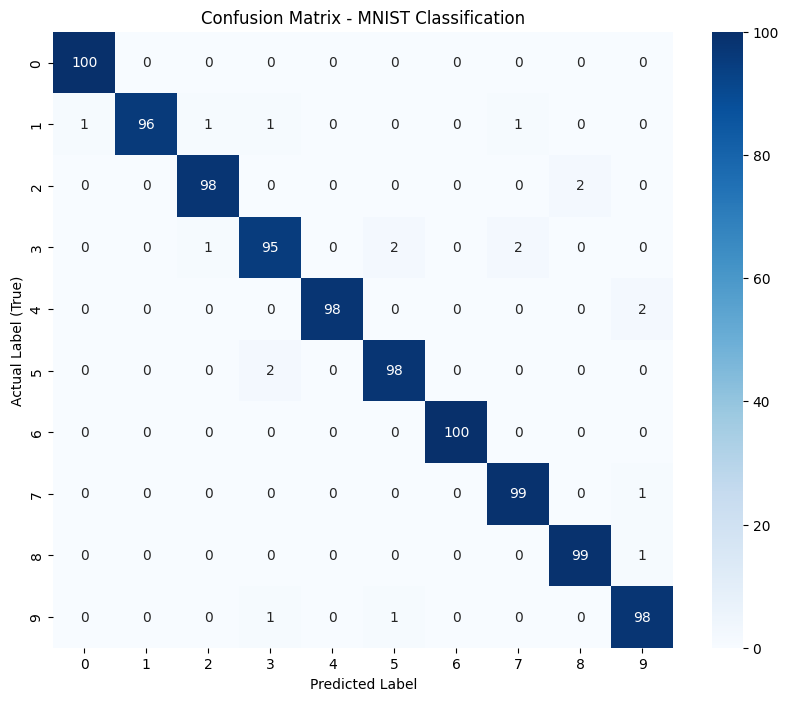

In [15]:
import os
import numpy as np
# Import library untuk confusion matrix dan visualisasi
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Inisialisasi list global untuk menampung semua data ---
y_true = []
y_pred = []

label_diff_dict = {}

for i in range(10):
    print("="*50)
    print("processing label", i)
    file_count = 0
    true_cnt = 0
    img_list = os.listdir(f"./image-hex-gen/mnist_img_{i}/")

    for img_file in img_list: # Mengubah nama 'img' di loop agar tidak tumpang tindih
        img_name = img_file.split(".")[0]
        image_path = os.path.join(f"./image-hex-gen/mnist_img_{i}/", img_file)
        
        img = load_mem_image(image_path, normalize=False)
        img = img.reshape(1, 28, 28)
        
        res = full_predict(img)
        
        # Jika hasil 'res' masih dalam bentuk array/tensor (misal: [3]), 
        # pastikan di-convert ke int biasa menggunakan int(res) atau res.item()
        pred_label = int(res) 
        
        # --- 2. Simpan label asli dan hasil prediksi ke list ---
        y_true.append(i)          # 'i' adalah label asli (0-9)
        y_pred.append(pred_label) # 'res' adalah hasil prediksi model
        
        file_count += 1
        if (pred_label == i):
            true_cnt += 1
    
    label_diff_dict[i] = true_cnt / file_count
    print("processing", file_count, "files for label", i, "accuracy", true_cnt / file_count)
    print("="*50)

# --- 3. Hitung Confusion Matrix setelah semua loop selesai ---
cm = confusion_matrix(y_true, y_pred)

# --- 4. Plot Visualisasi Confusion Matrix ---
plt.figure(figsize=(10, 8))
# annot=True untuk menampilkan angka di dalam kotak, fmt='d' format angka integer
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(range(10)), yticklabels=list(range(10)))

plt.title('Confusion Matrix - MNIST Classification')
plt.ylabel('Actual Label (True)')
plt.xlabel('Predicted Label')
plt.show()